In [16]:
import xarray as xr
from datetime import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import cartopy.crs as ccrs


In [2]:
lsm = xr.open_dataset('../land_sea_mask.nc')
lsm = lsm.isel(time=0).drop('time')

FWI_1980_2020 = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/FWI/FWI_1980_2020.nc").FWI
FWI_1980_2020['Longitude'] = FWI_1980_2020['Longitude'] - 360
FWI_1980_2020 = FWI_1980_2020.sel(Longitude=slice(lsm.longitude[0],lsm.longitude[-1]))


In [3]:
FWI_monthly = FWI_1980_2020.resample(Time='M').mean()
July = FWI_monthly.sel(Time=FWI_monthly.Time.dt.month.isin([7]))


In [24]:
July.Longitude

<xarray.DataArray 'Longitude' (Longitude: 77)>
array([-129.  , -128.75, -128.5 , -128.25, -128.  , -127.75, -127.5 , -127.25,
       -127.  , -126.75, -126.5 , -126.25, -126.  , -125.75, -125.5 , -125.25,
       -125.  , -124.75, -124.5 , -124.25, -124.  , -123.75, -123.5 , -123.25,
       -123.  , -122.75, -122.5 , -122.25, -122.  , -121.75, -121.5 , -121.25,
       -121.  , -120.75, -120.5 , -120.25, -120.  , -119.75, -119.5 , -119.25,
       -119.  , -118.75, -118.5 , -118.25, -118.  , -117.75, -117.5 , -117.25,
       -117.  , -116.75, -116.5 , -116.25, -116.  , -115.75, -115.5 , -115.25,
       -115.  , -114.75, -114.5 , -114.25, -114.  , -113.75, -113.5 , -113.25,
       -113.  , -112.75, -112.5 , -112.25, -112.  , -111.75, -111.5 , -111.25,
       -111.  , -110.75, -110.5 , -110.25, -110.  ])
Coordinates:
  * Longitude  (Longitude) float64 -129.0 -128.8 -128.5 ... -110.5 -110.2 -110.0

In [104]:
'''
Pearson's r
'''

import scipy

def calc_pearsons_r(da):
    
    lats = []
    lons = []
    rs = []
    ps = []

    for lat in da.Latitude.values:
        for lon in da.Longitude.values:
            cell_da = da.sel(Latitude=lat,Longitude=lon)

            x = cell_da.Time.dt.year.values.tolist()
            y = cell_da.values.tolist()

            if np.isnan(y).any():
                r,p = [math.nan,math.nan]

            else:
                r,p = scipy.stats.pearsonr(x,y)

            lats.append(lat)
            lons.append(lon)
            rs.append(r)
            ps.append(p)

    r_df = pd.DataFrame({"rs":rs,"lat":lats, "lon":lons})
    p_df = pd.DataFrame({"ps":ps,"lat":lats, "lon":lons})
    
    idx = pd.MultiIndex.from_arrays(arrays=[lats,lons], names=["lat","lon"])
    
    r_s = pd.Series(data=rs, index=idx)
    p_s = pd.Series(data=ps, index=idx)
    
    rs_da = xr.DataArray.from_series(r_s)
    rs_da = rs_da.rename('r')

    ps_da = xr.DataArray.from_series(p_s)
    ps_da = ps_da.rename('p')
    
    return([rs_da,ps_da])


In [7]:
July

<xarray.DataArray 'FWI' (Time: 41, Latitude: 101, Longitude: 77)>
array([[[ 0.10024676,  0.09934693,  0.12214157, ...,  5.2974677 ,
          5.8967414 ,  5.190833  ],
        [ 0.08649372,  0.10922246,  0.13453968, ...,  6.939745  ,
          5.949904  ,  5.535701  ],
        [ 0.10289354,  0.13633192,  0.14179389, ...,  8.3479595 ,
          8.081975  ,  7.230357  ],
        ...,
        [        nan,         nan,         nan, ..., 14.343158  ,
         18.157312  , 18.53109   ],
        [        nan,         nan,         nan, ..., 15.309761  ,
         16.513819  , 11.854718  ],
        [        nan,         nan,         nan, ..., 14.257172  ,
         12.479609  , 10.592518  ]],

       [[ 3.8319147 ,  5.0971985 ,  5.274866  , ...,  5.444698  ,
          5.598742  ,  5.501384  ],
        [ 4.956208  ,  4.4663367 ,  4.501312  , ...,  6.644721  ,
          5.639728  ,  5.6300964 ],
        [ 4.7239723 ,  4.154545  ,  4.3204436 , ...,  8.805432  ,
          8.15241   ,  8.387588  ],
...
        [        nan,         nan,         nan, ..., 22.662807  ,
         28.047127  , 29.542091  ],
        [        nan,         nan,         nan, ..., 25.3522    ,
         27.189987  , 21.443937  ],
        [        nan,         nan,         nan, ..., 26.274601  ,
         21.942806  , 18.87566   ]],

       [[ 0.28494674,  0.3113951 ,  0.36422536, ...,  2.3496137 ,
          2.4411578 ,  2.5505068 ],
        [ 0.29398328,  0.33812657,  0.3878004 , ...,  2.0856159 ,
          1.6641226 ,  1.765672  ],
        [ 0.3365622 ,  0.40235513,  0.4538299 , ...,  1.9598777 ,
          1.7127768 ,  1.9282111 ],
        ...,
        [        nan,         nan,         nan, ..., 20.36868   ,
         25.635569  , 25.723803  ],
        [        nan,         nan,         nan, ..., 22.22182   ,
         22.823357  , 19.623577  ],
        [        nan,         nan,         nan, ..., 21.8442    ,
         17.43521   , 13.897219  ]]], dtype=float32)
Coordinates:
  * Time       (Time) datetime64[ns] 1980-07-31 1981-07-31 ... 2020-07-31
  * Longitude  (Longitude) float64 -129.0 -128.8 -128.5 ... -110.5 -110.2 -110.0
  * Latitude   (Latitude) float64 55.0 54.75 54.5 54.25 ... 30.5 30.25 30.0

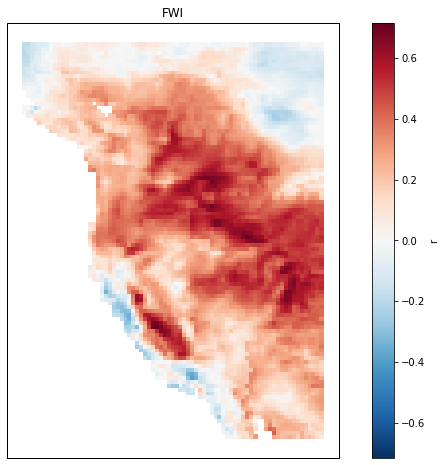

In [109]:

fig, ax = plt.subplots(figsize=(12,8), subplot_kw={'projection': ccrs.PlateCarree()})
    
[r,p] = calc_pearsons_r(July)

r.plot(ax=ax)
ax.set_title('FWI')

plt.savefig("FWI_trend.png",dpi=300)

In [ ]:
HadGEM3 = xr.open_dataset(file_path)['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
echam_gridarea = xr.open_dataset('/nesi/project/niwa00015/queenle/data/netcdfs/ECHAM_cellarea.nc')['cell_area']
merge = xr.merge([example_echam,echam_gridarea])
echam_da = merge.assign(converted = lambda merge: merge.mrro * merge.cell_area)


In [4]:
tasmax_HadGEM3 = xr.open_dataset("/nesi/project/niwa00015/queenle/data/HadGEM3/tasmax_All-Hist_HadGEM3.nc")

In [5]:
HadGEM3_orog = xr.open_dataset("~/../stoneda/data/C20C/MOHC/HadGEM3-A-N216/All-Hist/est1/v1-0/fx/atmos/orog/r0i0p0/orog_fx_HadGEM3-A-N216_All-Hist_est1_v1-0_r0i0p0_000000-000000.nc")
HadGEM3_sftlf = xr.open_dataset("~/../stoneda/data/C20C/MOHC/HadGEM3-A-N216/All-Hist/est1/v1-0/fx/atmos/sftlf/r0i0p0/sftlf_fx_HadGEM3-A-N216_All-Hist_est1_v1-0_r0i0p0_000000-000000.nc")


In [8]:
tasmax_HadGEM3['lon'] = tasmax_HadGEM3['lon'] - 360
HadGEM3_orog['lon'] = HadGEM3_orog['lon'] - 360
HadGEM3_sftlf['lon'] = HadGEM3_sftlf['lon'] - 360



In [25]:
box = tasmax_HadGEM3.sel(lon=slice(-129,-110),lat=slice(30,55))
box_orog = HadGEM3_orog.sel(lon=slice(-129,-110),lat=slice(30,55))
box_sftlf = HadGEM3_sftlf.sel(lon=slice(-129,-110),lat=slice(30,55))


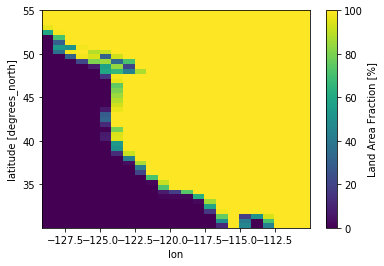

In [26]:
box_sftlf.sftlf.plot()

In [28]:
land_tasmax = box.tasmax.where(box_sftlf.sftlf > 20)

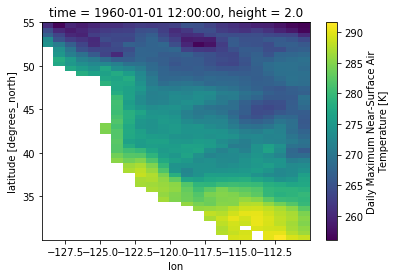

In [29]:
land_tasmax.isel(time=0).plot()

In [30]:
tasmax_monthly = land_tasmax.resample(time='M').mean()
July_tasmax = tasmax_monthly.sel(time=tasmax_monthly.time.dt.month.isin([7]))


In [31]:
'''
Pearson's r
'''

import scipy

def calc_pearsons_r(da):
    
    lats = []
    lons = []
    rs = []
    ps = []

    for lat in da.lat.values:
        for lon in da.lon.values:
            cell_da = da.sel(lat=lat,lon=lon)

            x = cell_da.time.dt.year.values.tolist()
            y = cell_da.values.flatten().tolist()

            if np.isnan(y).any():
                r,p = [math.nan,math.nan]

            else:
                r,p = scipy.stats.pearsonr(x,y)

            lats.append(lat)
            lons.append(lon)
            rs.append(r)
            ps.append(p)

    r_df = pd.DataFrame({"rs":rs,"lat":lats, "lon":lons})
    p_df = pd.DataFrame({"ps":ps,"lat":lats, "lon":lons})
    
    idx = pd.MultiIndex.from_arrays(arrays=[lats,lons], names=["lat","lon"])
    
    r_s = pd.Series(data=rs, index=idx)
    p_s = pd.Series(data=ps, index=idx)
    
    rs_da = xr.DataArray.from_series(r_s)
    rs_da = rs_da.rename('r')

    ps_da = xr.DataArray.from_series(p_s)
    ps_da = ps_da.rename('p')
    
    return([rs_da,ps_da])


In [96]:
July_tasmax.isel(lat=0,lon=0).values.flatten()

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan], dtype=float32)

In [86]:
calc_pearsons_r(July_tasmax)

<xarray.DataArray 'tasmax' (time: 56, height: 1)>
array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
...
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan]], dtype=float32)
Coordinates:
  * time     (time) object 1960-07-30 00:00:00 ... 2015-07-30 00:00:00
    lon      float32 -128.8
    lat      float32 30.28
  * height   (height) float32 2.0
<xarray.DataArray 'tasmax' (time: 56, height: 1)>
array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       

/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/ipykernel_launcher.py:39: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/ipykernel_launcher.py:40: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.


[<xarray.DataArray 'r' (lat: 0, lon: 0)>
 array([], shape=(0, 0), dtype=float64)
 Coordinates:
   * lat      (lat) object 
   * lon      (lon) object ,
 <xarray.DataArray 'p' (lat: 0, lon: 0)>
 array([], shape=(0, 0), dtype=float64)
 Coordinates:
   * lat      (lat) object 
   * lon      (lon) object ]

Text(0.5, 1.0, 'tasmax')

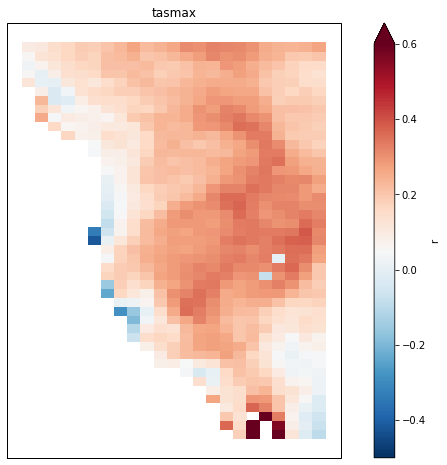

In [47]:
fig, ax = plt.subplots(figsize=(12,8), subplot_kw={'projection': ccrs.PlateCarree()})
    
[r,p] = calc_pearsons_r(July_tasmax)

r.plot(ax=ax,cmap='RdBu_r',vmin=-0.5,vmax=0.6)
ax.set_title('tasmax')

#plt.savefig('HadGEM3_tasmax_trend.png',dpi=300)

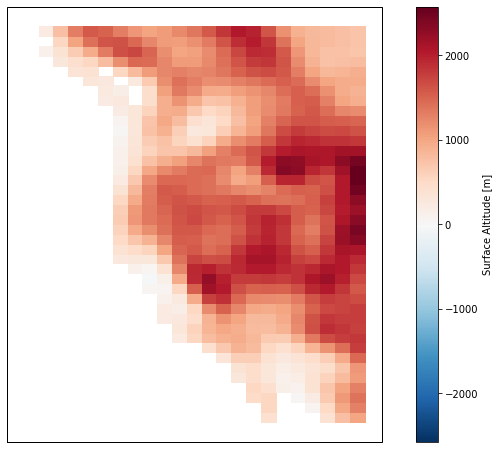

In [132]:
fig, ax = plt.subplots(figsize=(12,8), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_title('HadGEM3 Orography')

box_orog.orog.where(box_sftlf.sftlf > 50).plot(ax=ax)